## MATH 151 Lab 7

Dennis Hodgkins, Justus Languell, Kyle Miller

In [4]:
import sympy as sp
from sympy.plotting import (plot,plot_parametric)

### Question 1

#### 1a

In [40]:
x, y = sp.symbols('x y')
fx = 20 * x * (sp.E ** (3 - x ** 2))
dfx = sp.diff(fx, x)
crits = sp.solve(dfx, x)
int1 = dfx.subs(x, (crits[0] - 1)).evalf()

print(crits)
print(int1)

[-sqrt(2)/2, sqrt(2)/2]
-105.218535606392


#### 1b

In [41]:
int1 = dfx.subs(x, (crits[0] - 1)).evalf()
int2 = dfx.subs(x, 0).evalf()
int3 = dfx.subs(x, (crits[1] + 1)).evalf()

# print(int1,int2,int3)
max = fx.subs(x, crits[1])

print(f'The absolute maximum for the function is {max}')

The absolute maximum for the function is 10*sqrt(2)*exp(5/2)


### Question 2

In [12]:
a, b, x = sp.symbols('a b x')

fx = a * x * (sp.E ** (b * x ** 2))
dfx = sp.diff(fx, x)

bsub = sp.solve(fx - 4, a)

adfx = dfx.subs(a, bsub[0])

xadfx = adfx.subs(x, 8)

bval = sp.solve(xadfx, b)[0]

bfx = fx.subs(b, bval)

xbfx = bfx.subs(x, 8)

aval = sp.solve(xbfx-4, a)[0]

display(sp.Eq(a, aval))
display(sp.Eq(b, bval))

Eq(a, exp(1/2)/2)

Eq(b, -1/128)

### Question 3

#### 3a

In [19]:
x = sp.symbols('x')

fx = x ** 2 - 12
xvals = sp.solve(fx - x, x)

for xval in xvals:
    display(sp.Eq(x, xval))

Eq(x, -3)

Eq(x, 4)

#### 3b

In [20]:
c = sp.symbols('c')

dfx = sp.diff(fx, x)
cval = sp.solve(dfx - 1, x)[0]

display(sp.Eq(c, cval))

Eq(c, 1/2)

#### 3c

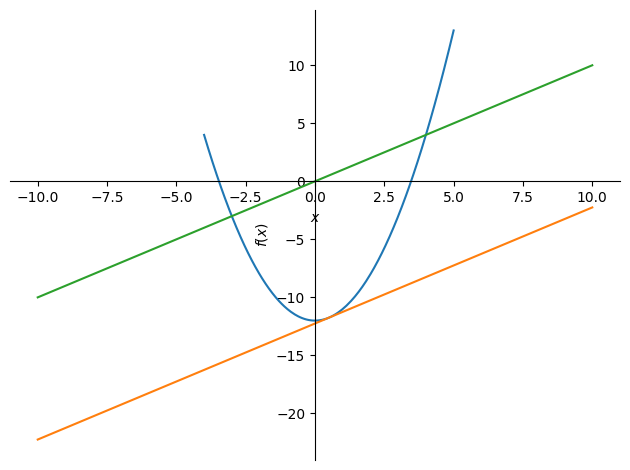

In [36]:
tan_y = fx.subs(x, cval)
tan_line = (x - cval) + tan_y

sec_y = fx.subs(x, xvals[0])
sec_line = (x - xvals[0]) + sec_y


plist = sp.plot(fx, (x, -4, 5), show=False)
plist.append(sp.plot(tan_line, show=False)[0])
plist.append(sp.plot(sec_line, show=False)[0])
plist.show()

### Question 4

#### 4a

In [37]:
# Given functions
x = sp.Symbol("x")
fl = 2 * sp.E**((x - 4) / 2) - x
fr = 10*x - 4*x**2 + 2

# Find derivative functions
flp = sp.diff(fl, x)
frp = sp.diff(fr, x)

# Find critical values
fl_crits = sp.solve(flp, x)
fr_crits = sp.solve(frp, x)

# Gather critical values that adhere to piecewise restrictions
f_crits = []
for i in range(len(fl_crits)):
  if fl_crits[i] <= 0:
    f_crits.append(fl_crits[i])
for i in range(len(fr_crits)):
  if fr_crits[i] > 0:
    f_crits.append(fr_crits[i])

# Check for a jump discontinuity critical point
if fl.subs(x, 0) != fr.subs(x, 0):
  f_crits.append(0)

# Print critical points
print(f_crits)

[5/4, 0]


#### 4b

In [38]:
# Generate list of possible extrema points
possibles = f_crits[:]
possibles.append(-2)
possibles.append(5)

# Find absolute maximum and minimum
max = possibles[0]
min = possibles[0]
if max <= 0:
  maxValue = fl.subs(x, max)
  mineValue = fl.subs(x, min)
else:
  maxValue = fr.subs(x, max)
  mineValue = fr.subs(x, min)

for possible in possibles:
  if possible <= 0:
    value = fl.subs(x, possible)
  else:
    value = fr.subs(x, possible)

  if value > maxValue:
    max = possible
    maxValue = value

for possible in possibles:
  if possible <= 0:
    value = fl.subs(x, possible)
  else:
    value = fr.subs(x, possible)

  if possible < maxValue:
    min = possible
    minValue = value

# Print absolute min and max values
print(f"On [-4, 5], f has an absolute maximum at x = {max}, where y = {maxValue}")
print(f"On [-4, 5], f has an absolute minimum at x = {min}, where y = {minValue}")

On [-4, 5], f has an absolute maximum at x = 5/4, where y = 33/4
On [-4, 5], f has an absolute minimum at x = 5, where y = -48


#### 4c

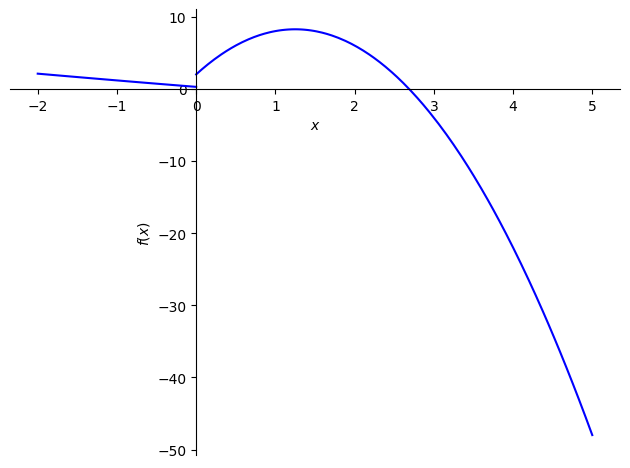

In [39]:
# Plot piecewise
left = sp.plot(fl, (x, -2, 0), show=False, line_color="Blue")
right = sp.plot(fr, (x, 0, 5), show=False, line_color="Blue")
left.extend(right)
left.show()